# 01 — Datos y splits

Este notebook **no entrena**. Prepara los conjuntos que usan 02, 03 y 05.
Paso 01 del flujo único (datos → … → comparar PCT).

1. Inventario de `bed-bpp_v1.json`.
2. Bloqueo de los 5 pedidos de `examples/5_bed-bpp.json` (holdout de producto: nunca train, val, test ni tuneo).
3. Split por `order_id` (70 / 15 / 15, semilla 42), **estratificado por target**.
4. Subconjunto de trabajo **aleatorio** (no los más cortos) en `data/train`, `data/val`, `data/test`.
5. Subconjunto scale (80 / 20 / 20) en `data/scale/` — lo usa el PPO del `05`.

Las comprobaciones de fuga y solape viven en `splits.materialize_splits` y `materialize_scale`. Al final deben existir los JSON de cada split.

In [1]:
from pathlib import Path
import sys

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

HERE = Path.cwd().resolve()
if HERE.name == "notebooks":
    ML_ROOT = HERE.parent
else:
    ML_ROOT = HERE if (HERE / "src_ml").is_dir() else Path("/home/edmundo/packing-services/online_policy_ml")

REPO_ROOT = ML_ROOT.parent
for p in (ML_ROOT / "src_ml", REPO_ROOT / "src"):
    s = str(p)
    if s not in sys.path:
        sys.path.insert(0, s)

from bootstrap import setup
setup()

import json
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

print("ML_ROOT =", ML_ROOT)
print("REPO_ROOT =", REPO_ROOT)

ML_ROOT = /home/edmundo/packing-services/online_policy_ml
REPO_ROOT = /home/edmundo/packing-services


In [2]:
from config import SCALE_COUNTS, SEED, SPLIT_FRACTIONS, WORKING_COUNTS
from paths import (
    DEMO_BED_BPP,
    HOLDOUT_DIR,
    REPORTS_DIR,
    SOURCE_BED_BPP,
    SPLITS_DIR,
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR,
    scale_split_dir,
)
from splits import (
    demo_order_ids,
    load_orders,
    materialize_scale,
    materialize_splits,
    order_item_count,
    order_target,
    scale_subset,
    split_order_ids,
    summarize_orders,
    working_subset,
)

assert SOURCE_BED_BPP.is_file(), f"No está el dataset grande: {SOURCE_BED_BPP}"
assert DEMO_BED_BPP.is_file(), f"No está el demo: {DEMO_BED_BPP}"

print("Fuente:", SOURCE_BED_BPP)
print("Demo (bloqueado):", DEMO_BED_BPP)
print("Semilla:", SEED, "| fracciones:", SPLIT_FRACTIONS)
print("Pedidos de trabajo por split:", WORKING_COUNTS)
print("Pedidos scale por split:", SCALE_COUNTS)

Fuente: /home/edmundo/bed-bpp-env/example_data/benchmark_data/bed-bpp_v1.json
Demo (bloqueado): /home/edmundo/packing-services/examples/5_bed-bpp.json
Semilla: 42 | fracciones: {'train': 0.7, 'val': 0.15, 'test': 0.15}
Pedidos de trabajo por split: {'train': 24, 'val': 8, 'test': 8}
Pedidos scale por split: {'train': 80, 'val': 20, 'test': 20}


## Inventario

Carga ~10 000 pedidos. Unidades mm / kg. Cada pedido es un `order_id`.

In [3]:
source_orders = load_orders(SOURCE_BED_BPP)
demo_orders = load_orders(DEMO_BED_BPP)
src_stats = summarize_orders(source_orders)
demo_stats = summarize_orders(demo_orders)

print("=== BED-BPP v1 ===")
for k, v in src_stats.items():
    print(f"  {k}: {v}")
print("\n=== examples/5_bed-bpp.json (holdout de producto) ===")
for k, v in demo_stats.items():
    print(f"  {k}: {v}")
print("\nIDs demo:", demo_order_ids())
print("Solape con v1:", sorted(set(demo_orders) & set(source_orders)))

=== BED-BPP v1 ===
  n_orders: 10003
  n_items_min: 14
  n_items_p50: 43
  n_items_mean: 42.85894231730481
  n_items_p90: 59
  n_items_max: 123
  targets: {'rollcontainer': 5471, 'euro-pallet': 4532}

=== examples/5_bed-bpp.json (holdout de producto) ===
  n_orders: 5
  n_items_min: 26
  n_items_p50: 38
  n_items_mean: 40.0
  n_items_p90: 58
  n_items_max: 58
  targets: {'euro-pallet': 2, 'rollcontainer': 3}

IDs demo: ['00100001', '00100002', '00100003', '00100004', '00100408']
Solape con v1: ['00100001', '00100002', '00100003', '00100004', '00100408']


In [4]:
rows = []
for oid, order in source_orders.items():
    rows.append({"order_id": oid, "n_items": order_item_count(order), "target": order_target(order)})
df_all = pd.DataFrame(rows)
display(df_all.groupby("target")["n_items"].describe().round(2))

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
euro-pallet,4532.0,50.82,12.84,22.0,43.0,51.0,57.0,123.0
rollcontainer,5471.0,36.27,10.74,14.0,31.0,38.0,43.0,96.0


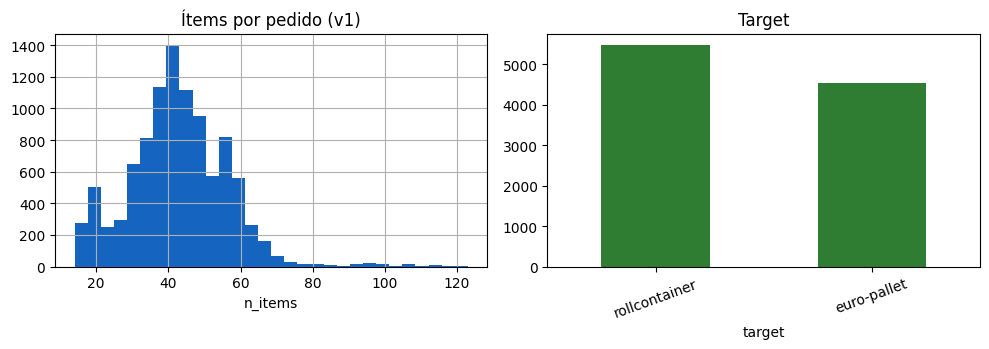

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
df_all["n_items"].hist(bins=30, ax=axes[0], color="#1565c0")
axes[0].set_title("Ítems por pedido (v1)")
axes[0].set_xlabel("n_items")
df_all["target"].value_counts().plot(kind="bar", ax=axes[1], color="#2e7d32")
axes[1].set_title("Target")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()

## Split por `order_id`

Los 5 demo **no entran** en train/val/test ni en scale. El subconjunto de trabajo es una **muestra aleatoria** de cada split (semilla 42). Scale es los primeros 80/20/20 del split ya barajado. El split completo queda en `data/splits/`.

In [6]:
blocked = demo_order_ids()
full_split = split_order_ids(source_orders.keys(), blocked=blocked, seed=SEED, orders=source_orders)
working = working_subset(full_split, source_orders)
scale = scale_subset(full_split)

for name, ids in full_split.items():
    leak = set(ids) & set(blocked)
    assert not leak, f"Fuga del demo en {name}: {leak}"
for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
    overlap = set(full_split[a]) & set(full_split[b])
    assert not overlap, f"Solape {a}/{b}: {len(overlap)}"

written = materialize_splits(source_orders, full_split, working, demo_orders)
written_scale = materialize_scale(source_orders, scale)

summary_rows = []
for name in ("train", "val", "test"):
    w_ids = working[name]
    counts = [order_item_count(source_orders[i]) for i in w_ids]
    summary_rows.append({
        "split": name,
        "n_ids_completos": len(full_split[name]),
        "n_trabajo": len(w_ids),
        "n_scale": len(scale[name]),
        "items_min": min(counts),
        "items_max": max(counts),
        "euro_pallet": sum(order_target(source_orders[i]) == "euro-pallet" for i in w_ids),
        "rollcontainer": sum(order_target(source_orders[i]) == "rollcontainer" for i in w_ids),
    })
df_split = pd.DataFrame(summary_rows)
display(df_split)

print("\nArchivos escritos:")
for key, path in {**written, **{f"scale_{k}": v for k, v in written_scale.items()}}.items():
    print(f"  {key}: {path}  exists={path.is_file()}")

,split,n_ids_completos,n_trabajo,n_scale,items_min,items_max,euro_pallet,rollcontainer
0,train,6999,24,80,18,64,13,11
1,val,1500,8,20,23,61,4,4
2,test,1499,8,20,31,95,6,2



Archivos escritos:
  source_pointer: /home/edmundo/packing-services/online_policy_ml/data/raw/source_pointer.json  exists=True
  train: /home/edmundo/packing-services/online_policy_ml/data/train/bed_bpp_orders.json  exists=True
  val: /home/edmundo/packing-services/online_policy_ml/data/val/bed_bpp_orders.json  exists=True
  test: /home/edmundo/packing-services/online_policy_ml/data/test/bed_bpp_orders.json  exists=True
  holdout_producto: /home/edmundo/packing-services/online_policy_ml/data/holdout_producto/5_bed-bpp.json  exists=True
  scale_train: /home/edmundo/packing-services/online_policy_ml/data/scale/train/bed_bpp_orders.json  exists=True
  scale_val: /home/edmundo/packing-services/online_policy_ml/data/scale/val/bed_bpp_orders.json  exists=True
  scale_test: /home/edmundo/packing-services/online_policy_ml/data/scale/test/bed_bpp_orders.json  exists=True


In [7]:
report = {
    "fase": 1,
    "seed": SEED,
    "source": str(SOURCE_BED_BPP),
    "n_orders_source": len(source_orders),
    "blocked_demo_ids": blocked,
    "full_split_counts": {k: len(v) for k, v in full_split.items()},
    "working_counts": {k: len(v) for k, v in working.items()},
    "scale_counts": {k: len(v) for k, v in scale.items()},
    "working_ids": working,
    "scale_ids": scale,
    "stats_source": src_stats,
}
out = REPORTS_DIR / "01_splits.json"
out.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding="utf-8")

assert (TRAIN_DIR / "bed_bpp_orders.json").is_file()
assert (VAL_DIR / "bed_bpp_orders.json").is_file()
assert (TEST_DIR / "bed_bpp_orders.json").is_file()
assert (HOLDOUT_DIR / "5_bed-bpp.json").is_file()
assert (SPLITS_DIR / "full_split.json").is_file()
for name in ("train", "val", "test"):
    assert (scale_split_dir(name) / "bed_bpp_orders.json").is_file()
    assert (scale_split_dir(name) / "order_ids.json").is_file()
print("OK — splits listos (trabajo + scale). Reporte:", out)

OK — splits listos (trabajo + scale). Reporte: /home/edmundo/packing-services/online_policy_ml/artifacts/reports/01_splits.json


Siguiente: `02_etiquetas_maestro.ipynb`.